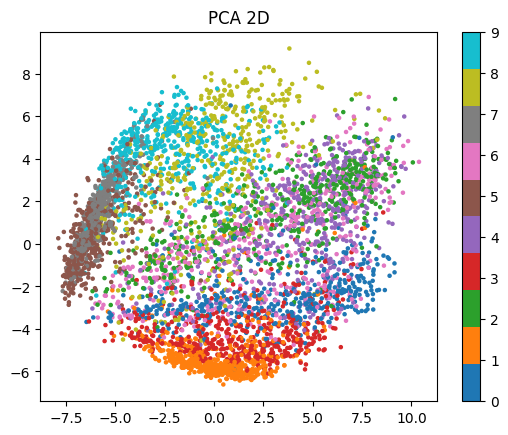

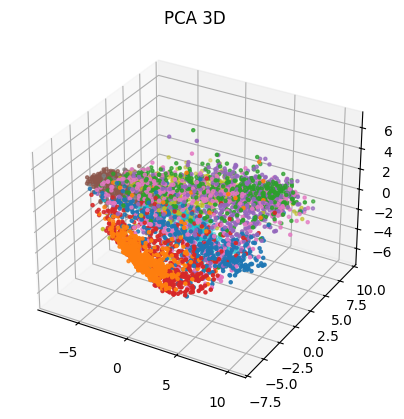

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# -----------------------------
# Load and Prepare Data
# -----------------------------
(x_train, y_train), (_, _) = fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0

# Flatten images (28x28 → 784)
x_flat = x_train.reshape(x_train.shape[0], -1)

# Use smaller sample for speed
sample = 5000
x_sample = x_flat[:sample]
y_sample = y_train[:sample]

# -----------------------------
# PCA (2D and 3D)
# -----------------------------
pca_2d = PCA(n_components=2)
x_pca_2d = pca_2d.fit_transform(x_sample)

plt.scatter(x_pca_2d[:,0], x_pca_2d[:,1], c=y_sample, cmap='tab10', s=5)
plt.title("PCA 2D")
plt.colorbar()
plt.show()

pca_3d = PCA(n_components=3)
x_pca_3d = pca_3d.fit_transform(x_sample)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_pca_3d[:,0], x_pca_3d[:,1], x_pca_3d[:,2], c=y_sample, cmap='tab10', s=5)
ax.set_title("PCA 3D")
plt.show()

# -----------------------------
# t-SNE (2D)
# -----------------------------
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
x_tsne = tsne.fit_transform(x_sample)

plt.scatter(x_tsne[:,0], x_tsne[:,1], c=y_sample, cmap='tab10', s=5)
plt.title("t-SNE 2D")
plt.colorbar()
plt.show()

# -----------------------------
# UMAP (2D)
# -----------------------------
umap_model = umap.UMAP(n_components=2, random_state=42)
x_umap = umap_model.fit_transform(x_sample)

plt.scatter(x_umap[:,0], x_umap[:,1], c=y_sample, cmap='tab10', s=5)
plt.title("UMAP 2D")
plt.colorbar()
plt.show()

# -----------------------------
# Autoencoder for Representation Learning
# -----------------------------
input_dim = 784
encoding_dim = 32

input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(encoding_dim, activation='relu')(encoded)

decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
encoder = Model(input_layer, encoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train Autoencoder
autoencoder.fit(x_sample, x_sample,
                epochs=5,
                batch_size=256,
                shuffle=True)

# Get encoded features
x_encoded = encoder.predict(x_sample)

# Visualize encoded features (first 2 dims)
plt.scatter(x_encoded[:,0], x_encoded[:,1], c=y_sample, cmap='tab10', s=5)
plt.title("Autoencoder Representation (2D Projection)")
plt.colorbar()
plt.show()

# -----------------------------
# Comparison Statement
# -----------------------------
print("\n--- Observations ---")
print("PCA is fast but shows overlapping clusters.")
print("t-SNE shows clear clusters but is slow.")
print("UMAP is faster than t-SNE and preserves structure well.")
print("Autoencoder learns compact feature representations.")